In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D,Dropout,BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import img_to_array, load_img

# Load dataset and split into training and test sets
data=cifar10.load_data()
((x_train,y_train),(x_test,y_test))=data

y_train = y_train.flatten()  # Convert labels from 2D to 1D
y_test = y_test.flatten()    # Flatten label array

# Normalize pixel values to range [0,1]
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')
x_train=x_train/255
x_test=x_test/255

# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']
print(class_names)

# Build CNN model
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

# Compile the model with Adam optimizer and sparse categorical crossentropy loss
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# Split training data into train and validation sets
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.2,random_state=42)

# Train the model
history=model.fit(x_train,y_train,epochs=20,validation_data=(x_val,y_val))

# Evaluate model on test data
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print(test_acc)

# Predict classes on test set
y_pred_prob=model.predict(x_test)
y_pred=np.argmax(y_pred_prob,axis=1)

# Load a custom image and prepare it for prediction

img = load_img('bird.webp', target_size=(32,32))  # directly resize
img_array = img_to_array(img) / 255.0             # convert to array and normalize
img_array = np.expand_dims(img_array, axis=0)     # add batch dimension

# Predict the class of the custom image
y_pred = model.predict(img_array)                  # use img_array here
pred_class = np.argmax(y_pred)

print("Predicted Class:", class_names[pred_class])

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4173 - loss: 1.6624 - val_accuracy: 0.5081 - val_loss: 1.3830
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6124 - loss: 1.0979 - val_accuracy: 0.6310 - val_loss: 1.0780
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6814 - loss: 0.9070 - val_accuracy: 0.6437 - val_loss: 1.0120
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7208 - loss: 0.8006 - val_accuracy: 0.6041 - val_loss: 1.1555
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7465 - loss: 0.7222 - val_accuracy: 0.6281 - val_loss: 1.1229
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7734 - loss: 0.6516 - val_accuracy: 0.6816 - val_loss: 0.9457
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7932 - loss: 0.5855 - val_accuracy: 0.6390 - val_loss: 1.152

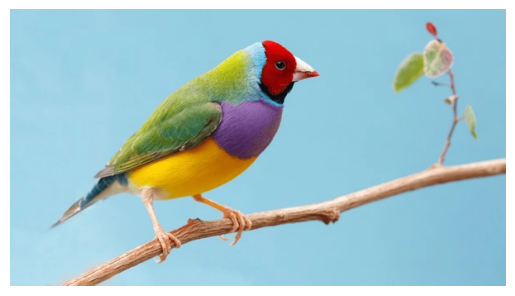

In [14]:
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt

# Load the image
img = load_img('bird.webp')  # PIL(python imaging library) image

# Display directly
plt.imshow(img)
plt.axis('off')  # hides axes
plt.show()